2026-08-15 17:04:25.287 | INFO     | __main__:llm_node:33 - ==============================
2026-08-15 17:04:25.288 | INFO     | __main__:llm_node:34 - 调用子图的 llm_node 节点，当前的 messages: 
2026-08-15 17:04:25.288 | INFO     | __main__:llm_node:36 - 
[消息 1]
类型：system
内容：用最简短的话回答用户的提问
2026-08-15 17:04:25.288 | INFO     | __main__:llm_node:36 - 
[消息 2]
类型：human
内容：5*5等于几
2026-08-15 17:04:25.288 | INFO     | __main__:llm_node:44 - ==============================
2026-08-15 17:04:26.753 | INFO     | __main__:llm_node:33 - ==============================
2026-08-15 17:04:26.753 | INFO     | __main__:llm_node:34 - 调用子图的 llm_node 节点，当前的 messages: 
2026-08-15 17:04:26.754 | INFO     | __main__:llm_node:36 - 
[消息 1]
类型：system
内容：用最简短的话回答用户的提问
2026-08-15 17:04:26.754 | INFO     | __main__:llm_node:36 - 
[消息 2]
类型：human
内容：10*10等于几
2026-08-15 17:04:26.755 | INFO     | __main__:llm_node:44 - ==============================
============================== -> 第一次运行结果 <- ==============================
{'user_i

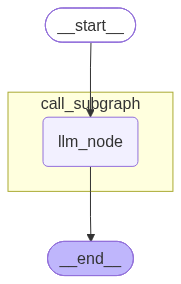

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	__end__([<p>__end__</p>]):::last
	__start__ --> call_subgraph\3allm_node;
	call_subgraph\3allm_node --> __end__;
	subgraph call_subgraph
	call_subgraph\3allm_node(llm_node)
	end
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from langchain.messages import HumanMessage, SystemMessage, AIMessage
from langchain_deepseek import ChatDeepSeek

import sys
from loguru import logger
logger.remove()
logger.add(sys.stdout, colorize=True)

import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv(override=True)
from rich import print as rprint

GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")
GEMINI_BASE_URL=os.getenv("GEMINI_BASE_URL")

model = init_chat_model(
  model="gemini-2.5-flash",
  model_provider="google_genai",
  api_key=GEMINI_API_KEY,
  transport="rest"  # 强制使用 REST 协议
)


# 构建子图
def llm_node(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    logger.info("=" * 30)
    logger.info("调用子图的 llm_node 节点，当前的 messages: ")
    for index, message in enumerate(messages, start=1):
        logger.opt(colors=True).info(
            "\n<cyan><bold>[消息 {}]</bold></cyan>\n"
            "<yellow>类型：</yellow><magenta>{}</magenta>\n"
            "<yellow>内容：</yellow><green>{}</green>",
            index,
            message.type,
            message.content
        )
    logger.info("=" * 30)
    response = model.invoke(input=messages)
    ai_msg = AIMessage(content=response.content)

    return {
        "messages": [ai_msg]
    }

builder = StateGraph(state_schema=MessagesState)
builder.add_node("llm_node", llm_node)
builder.add_edge(START, "llm_node")
builder.add_edge("llm_node", END)

# ==================================================
# 【策略切换点】只需修改这一行
subgraph = builder.compile()  # Per-invocation（默认）：每次调用状态隔离
# subgraph = builder.compile(checkpointer=True)   # Per-thread：历史相互干扰
# ==================================================

# 构建父图
class OverAllState(TypedDict):
    user_inputs: list[str] # 用户提问
    assistant_responses: str # 助手回答

def call_subgraph(state: OverAllState) -> OverAllState:
    user_inputs = state["user_inputs"]

    assistant_responses = []
    for user_input in user_inputs:
        subgraph_response = subgraph.invoke(
            {
                "messages": [
                    SystemMessage("用最简短的话回答用户的提问"),
                    HumanMessage(user_input)
                ]
            }
        )
        assistant_response = subgraph_response["messages"][-1].content
        assistant_responses.append(assistant_response)

    return {
        "assistant_responses": assistant_responses
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("call_subgraph", call_subgraph)
builder.add_edge(START, "call_subgraph")
builder.add_edge("call_subgraph", END)

checkpointer = InMemorySaver()
parent_graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "multi-call-same-demo"}}

first_response = parent_graph.invoke(
    {
        "user_inputs": [
            "5*5等于几",
            "10*10等于几"
        ]
    },
    config = config
)
print("=" * 30, "-> 第一次运行结果 <-", "=" * 30)
print(first_response)
#
# second_response = parent_graph.invoke(
#     {
#         "user_inputs": [
#             "再+10000呢?",
#             "再+1呢?"
#         ]
#     },
#     config = config
# )
# print("=" * 30, "-> 第二次运行结果 <-", "=" * 30)
# print(second_response)

from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)

raw_mermaid = parent_graph.get_graph(xray=True).draw_mermaid()
print(raw_mermaid)